<a href="https://colab.research.google.com/github/amrit-pratya/SmartCart-Clustering-System/blob/main/Smart_Cart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("/content/smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# Data Preprocessing

In [6]:
# Handling missing values
df["Income"] = df["Income"].fillna(df["Income"].mean())


In [7]:
# Feature engineering

from datetime import date

current_date = date.today()
current_year = current_date.year
#Age
df['Age'] = current_year-df['Year_Birth']

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

ref_date = pd.to_datetime(date.today())

df["Customer_Tenure_days"] = (ref_date - df["Dt_Customer"]).dt.days

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,4969
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,4419
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,4618
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,4445
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,4467


In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days'],
      dtype='object')

In [12]:
# Spending

df["Total_Spending"] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df[ 'MntGoldProds']

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,4969,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,4419,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,4618,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,4445,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,4467,422


In [14]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [15]:
# Education

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
    })

In [16]:
df["Education"].value_counts()

,count
Education,
Graduation,1127
Postgraduate,856
Undergraduate,257


In [17]:
# Marital Status

df["Living_with"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone",
    "YOLO": "Alone"
    })

In [18]:
df["Living_with"].value_counts()

,count
Living_with,
Partner,1444
Alone,796


# Dropping unnecessary columns

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_with
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,4969,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,4419,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,4618,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,4445,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,4467,422,1,Partner


In [20]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [21]:
df_cleaned.shape

(2240, 15)

In [22]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_with
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,4969,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,4419,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,4618,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,4445,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4467,422,1,Partner


# Outliers

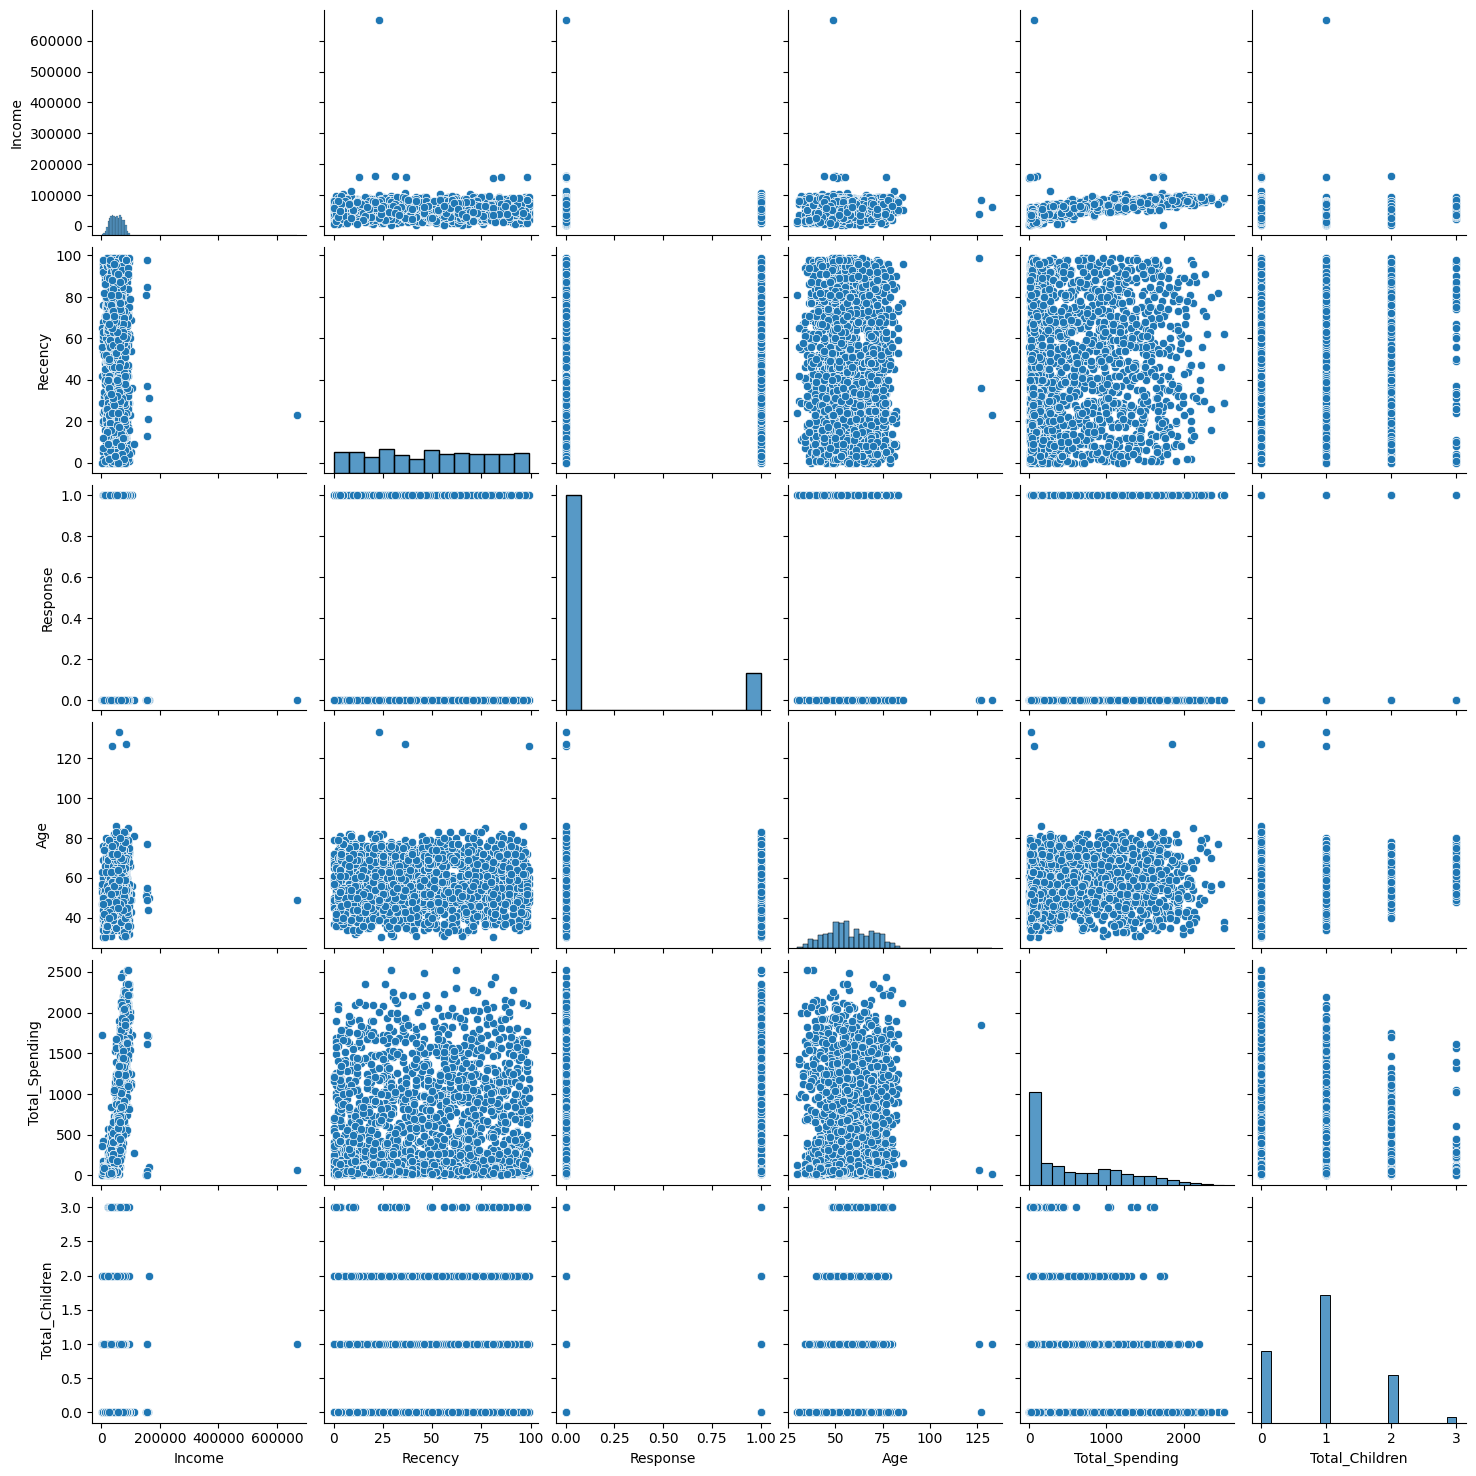

In [23]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features:

sns.pairplot(df_cleaned[cols])
plt.show()

In [24]:
# Remove the outliers

print("Data Size With Outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned['Age']< 90)]
df_cleaned = df_cleaned[(df_cleaned['Income']< 600_000)]

print("Data Size Without Outliers:", len(df_cleaned))

Data Size With Outliers: 2240
Data Size Without Outliers: 2236


# Heatmap

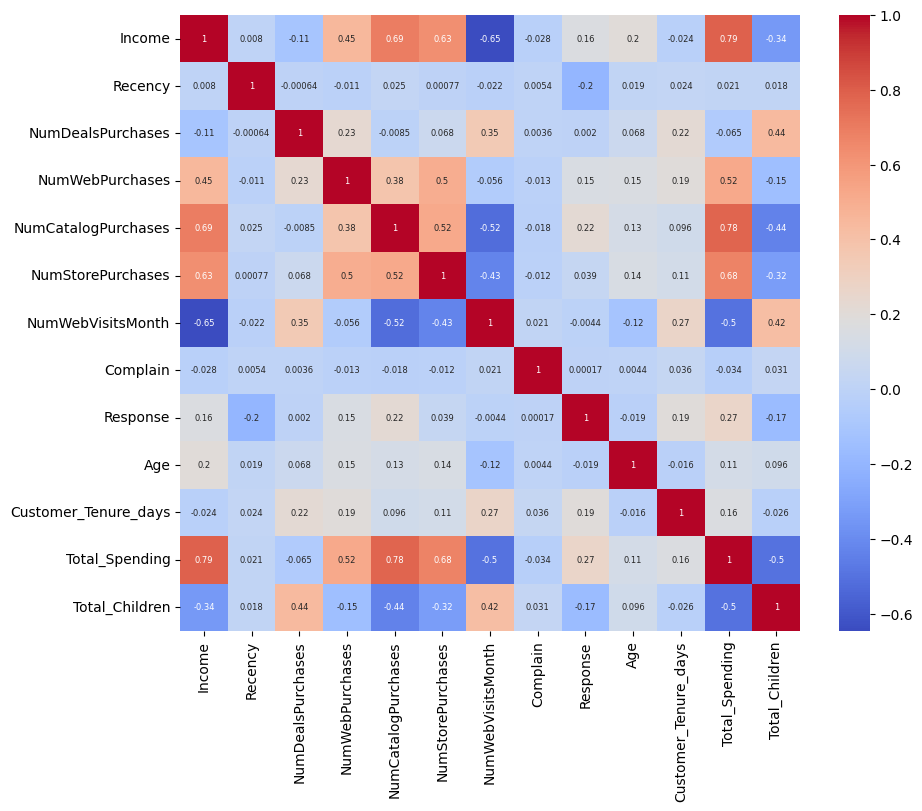

In [25]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, annot_kws={"size": 6}, cmap='coolwarm')
plt.show()

In [26]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_with
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,4969,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,4419,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,4618,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,4445,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4467,422,1,Partner


# Encoding

In [27]:
from sklearn.preprocessing import OneHotEncoder


In [28]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

encoded_data = ohe.fit_transform(df_cleaned[cat_cols])
encoded_df = pd.DataFrame(encoded_data.toarray(), columns=ohe.get_feature_names_out(cat_cols,), index=df_cleaned.index)
encoded_df = pd.concat([df_cleaned.drop(columns=cat_cols), encoded_df], axis=1)


In [29]:
encoded_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,4969,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,4419,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,4618,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,4445,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,4467,422,1,0.0,1.0,0.0,0.0,1.0


In [30]:
X = encoded_df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize

In [31]:

X_scaled.shape

(2236, 18)

In [32]:
from sklearn.decomposition import PCA

In [33]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [34]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

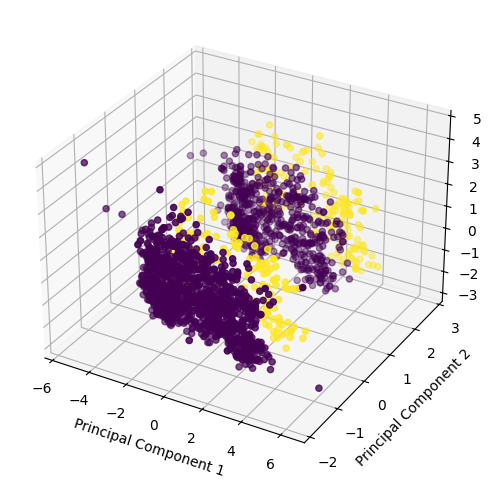

In [35]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df_cleaned['Response'], cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

In [36]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

# Analyze K value

In [37]:
# 1 Elbow method
!pip install kneed
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [38]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.knee
print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 4


Text(0.5, 1.0, 'Elbow Method')

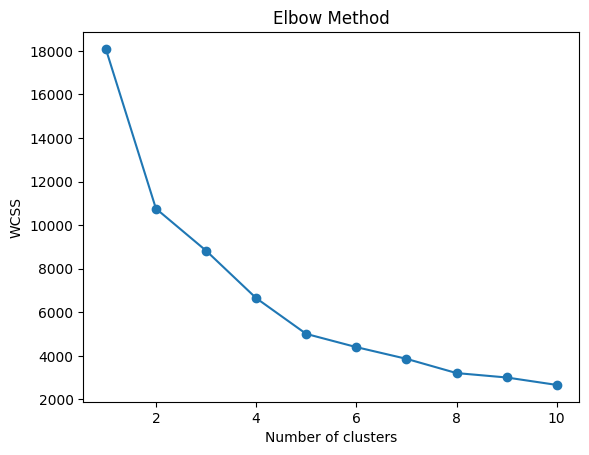

In [39]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

Text(0.5, 1.0, 'Silhouette Score Method')

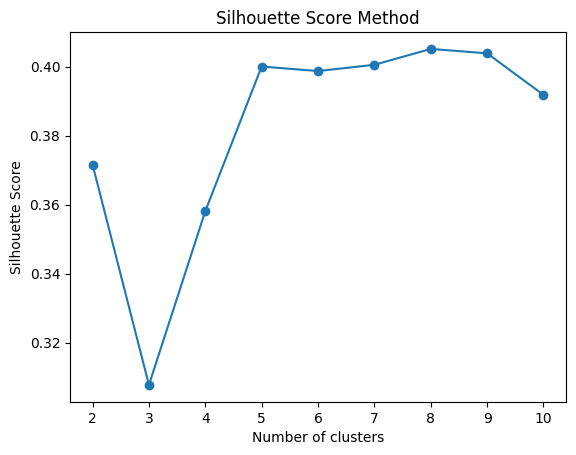

In [40]:
# 2 Silhoutte score
from sklearn.metrics import silhouette_score

score = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score.append(silhouette_score(X_pca, labels))

plt.plot(range(2, 11), score, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')

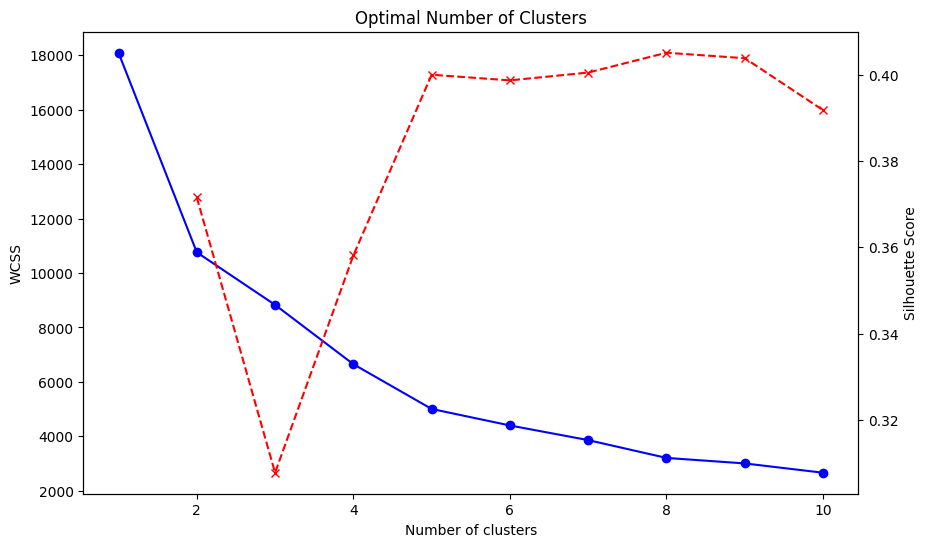

In [41]:
from matplotlib.lines import lineStyles
# Combined Plot
K_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Elbow
ax1.plot(range(1, 11), wcss, marker='o', color='blue')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('WCSS')


# Plot Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, score[:len(K_range)], marker='x', color='red', linestyle='--')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')

plt.title('Optimal Number of Clusters')
plt.show()

In [42]:
# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

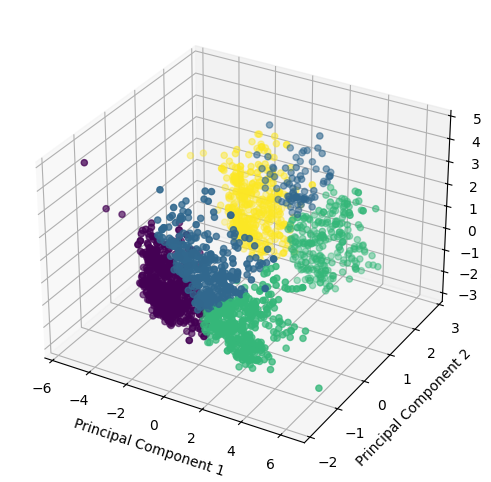

In [43]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans, cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

In [44]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

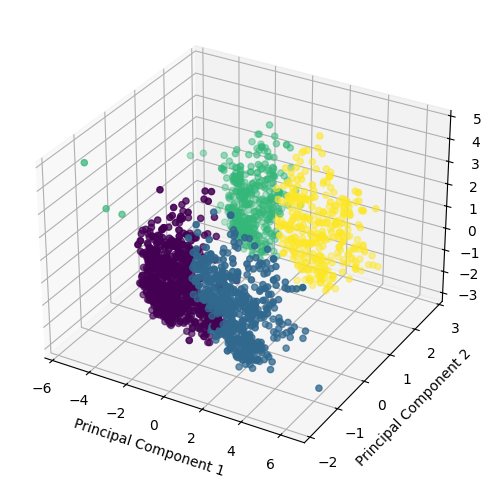

In [45]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg, cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

# Characterisation of Clusters

In [47]:

X['cluster'] = labels_agg

In [48]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_with
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,4969,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,4419,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,4618,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,4445,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4467,422,1,Partner


<Axes: xlabel='cluster', ylabel='count'>

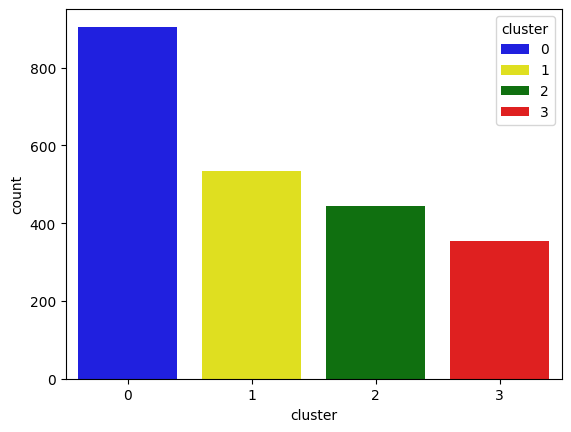

In [49]:
pal = ['blue', 'yellow', 'green', 'red']
sns.countplot(x=X['cluster'], hue=X['cluster'], palette=pal)

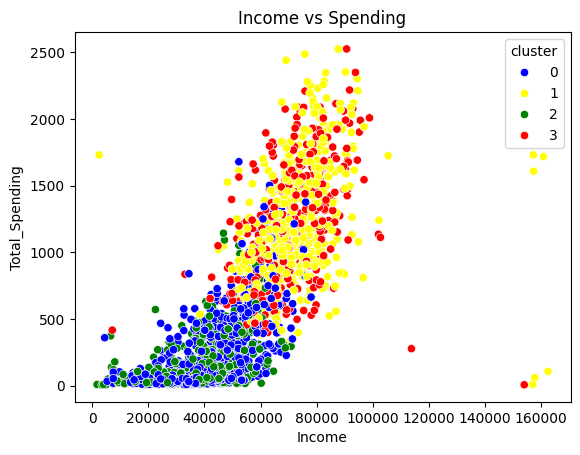

In [50]:
#  Income & Spending patterns

sns.scatterplot(x=X['Income'], y=X['Total_Spending'], hue=X['cluster'], palette=pal)
plt.title('Income vs Spending')
plt.show()

In [51]:
# cluster_summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_days  Total_Spending  \
cluster         

In [52]:
# 1. Install Gradio
!pip install -q gradio

import gradio as gr
import pandas as pd
import numpy as np
from datetime import date
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- DATA PREPARATION & MODEL TRAINING ---
# (Simulating the model state based on your Smart_Cart.ipynb logic)
df = pd.read_csv("/content/smartcart_customers.csv")

# Preprocessing logic from your notebook
df["Income"] = df["Income"].fillna(df["Income"].mean())
current_year = date.today().year
df['Age'] = current_year - df['Year_Birth']
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Tenure_days"] = (pd.to_datetime(date.today()) - df["Dt_Customer"]).dt.days
df["Total_Spending"] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Selecting features used for clustering
features = ["Income", "Age", "Customer_Tenure_days", "Total_Spending", "Total_Children"]
X = df[features]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Training K-Means (Setting K=4 based on your analysis)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1)

# --- INFERENCE FUNCTION ---
def predict_cluster(income, birth_year, total_spending, kids, teens):
    # Process inputs
    input_age = current_year - birth_year
    total_children = kids + teens
    # Assuming "average" tenure for a new prediction
    avg_tenure = df["Customer_Tenure_days"].mean()

    # Create array for scaling
    input_data = np.array([[income, input_age, avg_tenure, total_spending, total_children]])
    input_scaled = scaler.transform(input_data)

    # Predict
    cluster_id = kmeans.predict(input_scaled)[0]

    # Insights based on your notebook analysis
    cluster_map = {
        0: "Moderate Spender / Larger Family",
        1: "High-Income / Premium Spender (Meat & Wine focus)",
        2: "Budget-Conscious / High Household size",
        3: "Elite Spender / Loyal Customer"
    }

    return f"Customer belongs to Cluster {cluster_id}", cluster_map.get(cluster_id, "Unknown Segment")

# --- GRADIO INTERFACE ---
interface = gr.Interface(
    fn=predict_cluster,
    inputs=[
        gr.Number(label="Yearly Income ($)", value=50000),
        gr.Number(label="Birth Year", value=1980),
        gr.Slider(0, 3000, label="Total Spending ($)", value=500),
        gr.Dropdown([0, 1, 2], label="Kids at Home", value=0),
        gr.Dropdown([0, 1, 2], label="Teens at Home", value=0)
    ],
    outputs=[
        gr.Textbox(label="Predicted Group"),
        gr.Textbox(label="Segment Profile")
    ],
    title="SmartCart Customer Segmentation 🛒",
    description="Input customer data to see which marketing segment they fall into based on our K-Means model."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c0b3f649ee7debf820.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
